# Pipeline for the anomaly detection on the SKAB using Feed Forward Autoencoder

Details regarding the SKAB one can find in the [SKAB repository](https://github.com/waico/SKAB).

## Libraries importing

In [1]:
# libraries importing
import sys
import warnings

import pandas as pd
from sklearn.preprocessing import StandardScaler

sys.path.append("..")
from core.Vanilla_AE_pytorch import Vanilla_AE
from core.metrics import chp_score
from core.utils import load_preprocess_skab, plot_results

warnings.filterwarnings("ignore", category=UserWarning)

import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from core.plot_learning_curve import plot_learning_curve



## Data

In [2]:
Xy_traintest_list = load_preprocess_skab()

## Method

### Method initialization

In [3]:
# hyperparameters selection
BEST_PARAMS = [5, 4, 2, 0.005, 32]
Q = 0.99  # quantile for upper control limit (UCL) selection

In [4]:
# model defining
model = Vanilla_AE(BEST_PARAMS)

### Method fitting and applying

In [5]:
# inference
predicted_outlier, predicted_cp = [], []
true_outlier, true_cp = [], []
all_scores = []

for X_train, X_test, y_train, y_test in Xy_traintest_list:

    # scaler init and fitting
    StSc = StandardScaler()
    StSc.fit(X_train)

    X_train_sc = StSc.transform(X_train)
    X_test_sc = StSc.transform(X_test)

    # model fitting
    model.fit(X_train_sc)

    # results predicting
    residuals_train = (
        pd.DataFrame(X_train_sc - model.predict(X_train_sc))
        .abs()
        .sum(axis=1)
    )
    

    Q = 0.99
    UCL = residuals_train.quantile(Q) * 5 / 2

    residuals_test = pd.DataFrame(
        X_test_sc - model.predict(X_test_sc)
    ).abs().sum(axis=1)

   

    all_scores.append(residuals_test)
    
    print((residuals_test > UCL).sum())

    prediction = pd.Series(
    (residuals_test > UCL).to_numpy(),
    index=X_test.index,
    dtype=int
    )


    

    predicted_outlier.append(prediction)

    prediction_cp = prediction.diff().abs()
    prediction_cp.iloc[0] = prediction.iloc[0]
    predicted_cp.append(prediction_cp)

    true_outlier.append(y_test["anomaly"])
    true_cp.append(y_test["changepoint"])

8
688
0
231
0
318
0
0
0
452
402
347
41
395
1
1
0
0
226
159
0
343
0
0
0
0
0
0
0
38
44
0
0
0


Zapisano: images/lc_vanilla_ae.png


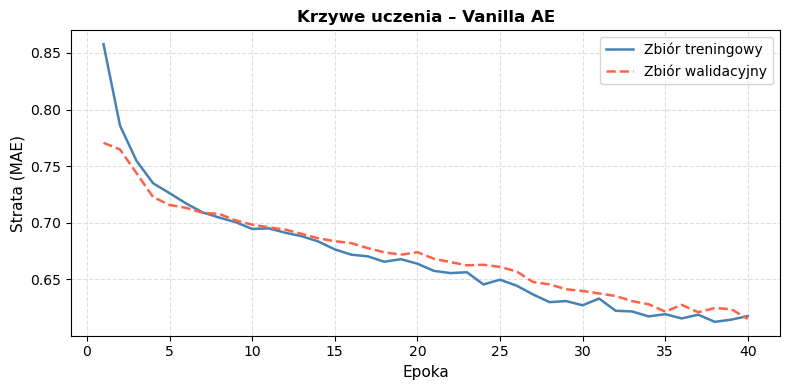

In [6]:


os.makedirs("images", exist_ok=True)

plot_learning_curve(
    model,
    'Vanilla AE',
    save_path='images/lc_vanilla_ae.png'
)

### Results visualization

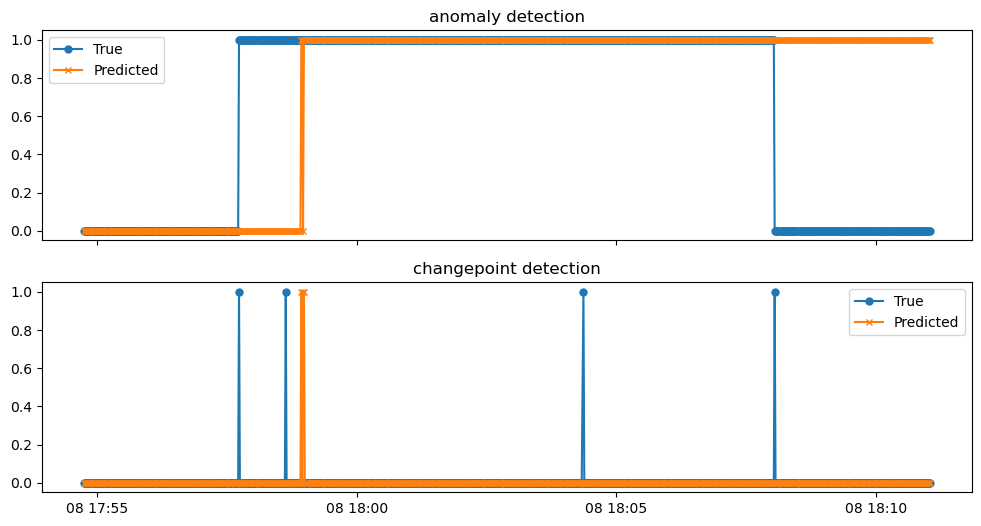

In [7]:
# [donotremove]
plot_results(
    (true_outlier[1], predicted_outlier[1]),
    (true_cp[1], predicted_cp[1]),
)

## Evaluation (metrics calculation)

In [8]:
import pickle

pickle.dump(
    predicted_outlier,
    open(f"../results/results-{model.__class__.__name__}.pkl", "wb"),
)

### Binary classification (outlier detection) metrics

In [9]:
# [donotremove]
# binary classification metrics calculation
binary = chp_score(true_outlier, predicted_outlier, metric="binary")

False Alarm Rate 3.28 %
Missing Alarm Rate 73.91 %
F1 metric 0.4


### Changepoint detection metrics

In [10]:
# [donotremove]
# average detection delay metric calculation
add = chp_score(
    true_cp,
    predicted_cp,
    metric="average_time",
    window_width="60s",
    anomaly_window_destination="righter",
)

Amount of true anomalies 127
A number of missed CPs = 101
A number of FPs = 224
Average time 0 days 00:00:08.192307


In [11]:
# [donotremove]
# nab metric calculation
nab = chp_score(
    true_cp,
    predicted_cp,
    metric="nab",
    window_width="60s",
    anomaly_window_destination="righter",
)

Standard  -  9.52
LowFP  -  -0.3
LowFN  -  13.17


Zapisano ROC: images/roc_vanilla_ae.png


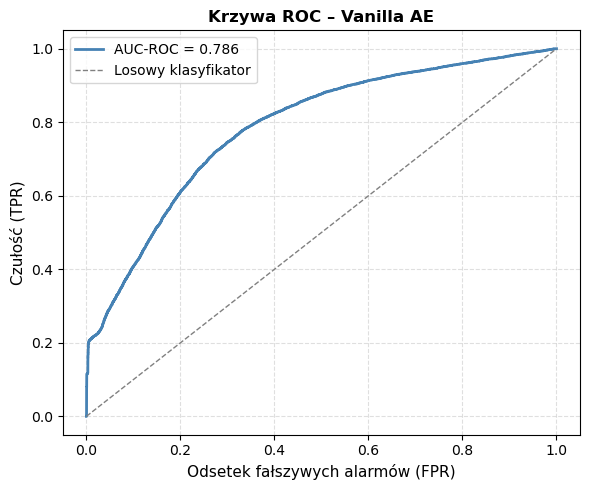

Zapisano PR: images/pr_vanilla_ae.png


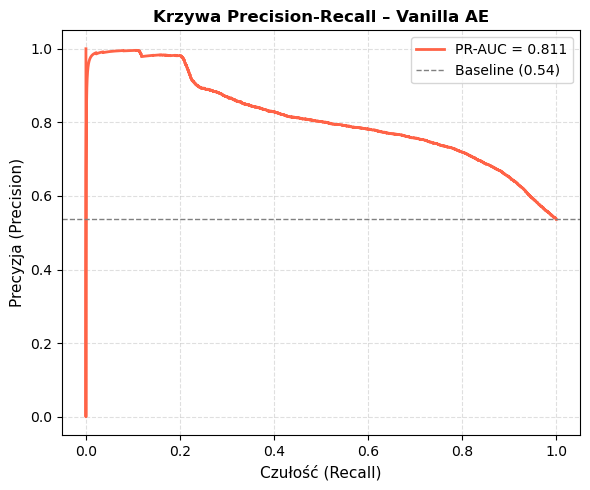


Model:    Vanilla AE
AUC-ROC:  0.7856
PR-AUC:   0.8114
MCC:      0.4461  (próg optymalny = 9.8021)

{'auc_roc': 0.7856, 'pr_auc': 0.8114, 'mcc': 0.4461}


In [12]:
from core.plot_roc_pr import plot_roc_pr

metrics = plot_roc_pr(
    scores_list = all_scores,
    labels_list = true_outlier,
    model_name  = 'Vanilla AE',
    save_roc    = 'images/roc_vanilla_ae.png',
    save_pr     = 'images/pr_vanilla_ae.png',
)
print(metrics)

In [13]:
import numpy as np
from pathlib import Path

Path('results').mkdir(exist_ok=True)

# Zapisz jako object array (lista list różnych długości)
np.save('results/scores_vanilla_ae.npy', 
        np.array(all_scores, dtype=object), 
        allow_pickle=True)
np.save('results/labels_vanilla_ae.npy', 
        np.array(true_outlier, dtype=object), 
        allow_pickle=True)

In [14]:
import numpy as np
from pathlib import Path

Path('results').mkdir(exist_ok=True)

# Sprawdź co masz
print("Typ all_scores:", type(all_scores))
print("Długość:", len(all_scores))
print("Pierwszy element typ:", type(all_scores[0]))
print("Pierwszy element długość:", len(all_scores[0]))
print()
print("Typ true_outlier:", type(true_outlier))
print("Długość:", len(true_outlier))
print("Pierwszy element typ:", type(true_outlier[0]))

Typ all_scores: <class 'list'>
Długość: 34
Pierwszy element typ: <class 'pandas.Series'>
Pierwszy element długość: 345

Typ true_outlier: <class 'list'>
Długość: 34
Pierwszy element typ: <class 'pandas.Series'>


In [15]:
import pickle
from pathlib import Path

Path('results_npy').mkdir(exist_ok=True)

# Zapisz jako pickle - zachowuje format pandas Series
with open('results_npy/scores_vanilla_ae.pkl', 'wb') as f:
    pickle.dump(all_scores, f)

with open('results_npy/labels_vanilla_ae.pkl', 'wb') as f:
    pickle.dump(true_outlier, f)

print("Zapisano scores i labels dla Vanilla AE")

Zapisano scores i labels dla Vanilla AE


In [16]:
import numpy as np

scores = np.load(
    r'C:\Users\olegs\Studia 3 semestr\Skab-Master\notebooks\results\scores_vanilla_ae.npy',
    allow_pickle=True
)
labels = np.load(
    r'C:\Users\olegs\Studia 3 semestr\Skab-Master\notebooks\results\labels_vanilla_ae.npy',
    allow_pickle=True
)

print("SCORES:")
print(f"  Typ: {type(scores)}")
print(f"  Długość (eksperymenty): {len(scores)}")
print(f"  Pierwszy eksperyment - typ: {type(scores[0])}")
print(f"  Pierwsze 5 wartości: {scores[0][:5]}")
print()
print("LABELS:")
print(f"  Długość (eksperymenty): {len(labels)}")
print(f"  Unikalne wartości: {np.unique(np.concatenate([l for l in labels]))}")
print(f"  Suma anomalii łącznie: {sum(l.sum() for l in labels)}")

SCORES:
  Typ: <class 'numpy.ndarray'>
  Długość (eksperymenty): 34
  Pierwszy eksperyment - typ: <class 'pandas.Series'>
  Pierwsze 5 wartości: 0    6.462947
1    5.430510
2    3.786586
3    6.263900
4    3.589965
dtype: float64

LABELS:
  Długość (eksperymenty): 34
  Unikalne wartości: [0. 1.]
  Suma anomalii łącznie: 12771.0


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Wczytaj
scores = np.load('results/scores_vanilla_ae.npy', allow_pickle=True)
labels = np.load('results/labels_vanilla_ae.npy', allow_pickle=True)

# Spłaszcz 34 eksperymenty do jednej tablicy
scores_flat = np.concatenate([s.values if hasattr(s, 'values') else s for s in scores])
labels_flat = np.concatenate([l.values if hasattr(l, 'values') else l for l in labels])

print(f"Scores: {len(scores_flat)} próbek, min={scores_flat.min():.4f}, max={scores_flat.max():.4f}")
print(f"Labels: anomalie={labels_flat.sum()}, normalne={len(labels_flat)-labels_flat.sum()}")

Scores: 23801 próbek, min=0.7996, max=619.5795
Labels: anomalie=12771.0, normalne=11030.0


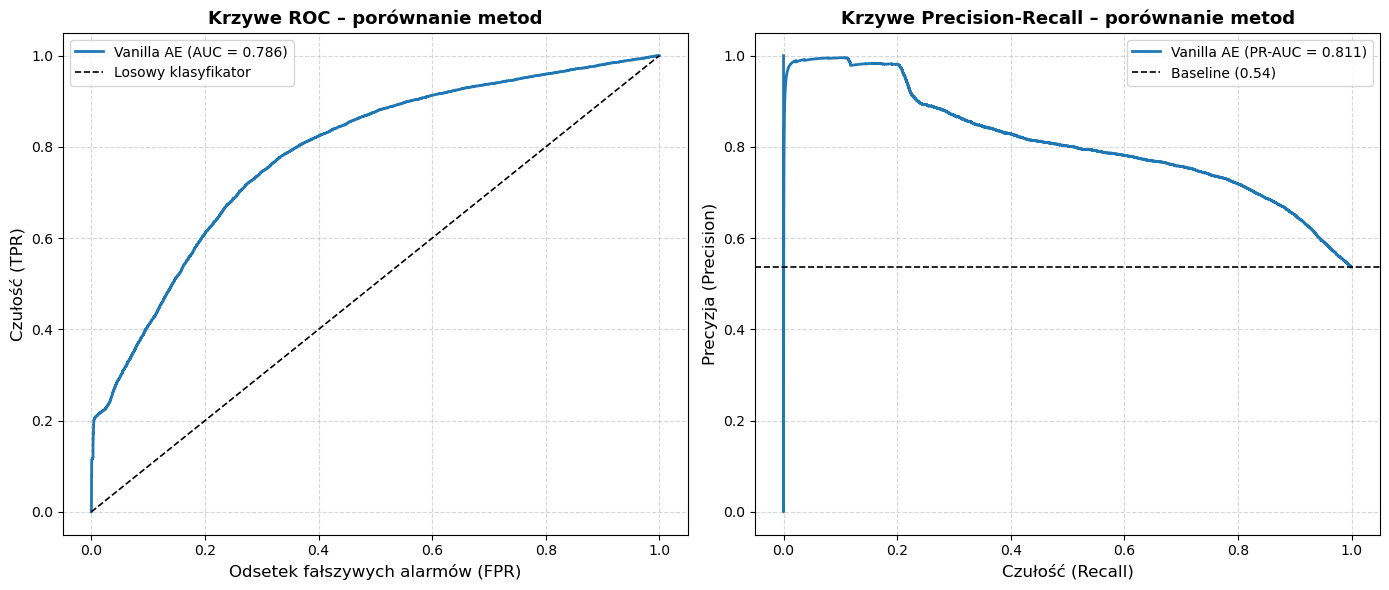

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# --- Wczytaj dane ---
scores = np.load('results/scores_vanilla_ae.npy', allow_pickle=True)
labels = np.load('results/labels_vanilla_ae.npy', allow_pickle=True)
scores_flat = np.concatenate([s.values if hasattr(s, 'values') else s for s in scores])
labels_flat = np.concatenate([l.values if hasattr(l, 'values') else l for l in labels])

# --- ROC ---
fpr, tpr, _ = roc_curve(labels_flat, scores_flat)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, lw=2, label=f'Vanilla AE (AUC = {roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1.2, label='Losowy klasyfikator')
axes[0].set_xlabel('Odsetek fałszywych alarmów (FPR)', fontsize=12)
axes[0].set_ylabel('Czułość (TPR)', fontsize=12)
axes[0].set_title('Krzywe ROC – porównanie metod', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- PR ---
precision, recall, _ = precision_recall_curve(labels_flat, scores_flat)
pr_auc = auc(recall, precision)
baseline = labels_flat.mean()

axes[1].plot(recall, precision, lw=2, label=f'Vanilla AE (PR-AUC = {pr_auc:.3f})')
axes[1].axhline(y=baseline, color='k', linestyle='--', lw=1.2, label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Czułość (Recall)', fontsize=12)
axes[1].set_ylabel('Precyzja (Precision)', fontsize=12)
axes[1].set_title('Krzywe Precision-Recall – porównanie metod', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('images/roc_pr_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print(type(model.history))
print(model.history.keys())
print("Epoki:", len(model.history['train_loss']))

<class 'dict'>
dict_keys(['train_loss', 'val_loss'])
Epoki: 40


In [20]:
print(len(all_scores))
print(type(all_scores[0]))
print(all_scores[0][:5])

34
<class 'pandas.Series'>
0    6.462947
1    5.430510
2    3.786586
3    6.263900
4    3.589965
dtype: float64
